# Data understanding


In [1]:
# importing libraries
import pandas as pd
import sqlite3

In [2]:
# loading data sets
bom_df= pd.read_csv("..\data/bom.movie_gross.csv")
rt_reviews_df=pd.read_csv("..\data/rt.reviews.tsv", sep= '\t', encoding= 'latin1') 
rt_movie_info_df= pd.read_csv("..\data/rt.movie_info.tsv", sep= '\t', encoding= 'latin1')
tmdb_movies_df= pd.read_csv("..\data/tmdb.movies.csv")
tn_movie_budgets_df= pd.read_csv("..\data/tn.movie_budgets.csv")

# previewing each
for name, df in [('Box office mojo', bom_df), ('Rotten tomatoes Reviews', rt_reviews_df), ('Rotten tomatoes movie info', rt_movie_info_df),
                 ('The movie DB',tmdb_movies_df), ('The numbers', tn_movie_budgets_df)]:
    print(f"\n{name} Sample:")
    print(df.head())
    print(df.info())



Box office mojo Sample:
                                         title studio  domestic_gross  \
0                                  Toy Story 3     BV     415000000.0   
1                   Alice in Wonderland (2010)     BV     334200000.0   
2  Harry Potter and the Deathly Hallows Part 1     WB     296000000.0   
3                                    Inception     WB     292600000.0   
4                          Shrek Forever After   P/DW     238700000.0   

  foreign_gross  year  
0     652000000  2010  
1     691300000  2010  
2     664300000  2010  
3     535700000  2010  
4     513900000  2010  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year       

## Data understanding of each dataframe

In [3]:
#Box office mojo dataset(movie_gross)
# checking the shape
bom_df.shape

(3387, 5)

bom_df dataframe from Box office Mojo has 3387 records and 5 columns.

In [4]:
# checking the info
bom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


## Observation

Total rows: 3387 movies

Columns: 5 - title, studio, domestic_gross, foreign_gross and year.

The dataset is mostly complete with title and year having no missing values

The column with more missing values is foreign_gross followed by domestic_gross and lastly studio.

foreign_gross is stored as object instead of float, likely due to formatting issues.


In [5]:
# reviewing Rotten Tomatoes dataset 
rt_reviews_df.info()
print(rt_reviews_df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54432 entries, 0 to 54431
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          54432 non-null  int64 
 1   review      48869 non-null  object
 2   rating      40915 non-null  object
 3   fresh       54432 non-null  object
 4   critic      51710 non-null  object
 5   top_critic  54432 non-null  int64 
 6   publisher   54123 non-null  object
 7   date        54432 non-null  object
dtypes: int64(2), object(6)
memory usage: 3.3+ MB
(54432, 8)


In [6]:
# checking missing values
rt_reviews_df.isna().sum()

id                0
review         5563
rating        13517
fresh             0
critic         2722
top_critic        0
publisher       309
date              0
dtype: int64

## Observation

Total rows: 54,432 reviews

Columns: 8 including id, review, rating, fresh, critic, top_critic, publisher, and date

All rows have id, fresh, top_critic, and date

missing values are significant in some columns

- review: 5563 missing values

- rating: 13517 missing

- rating: 13517 missing

- publisher: 309 missing values

Date column can be converted to date-time format



In [7]:
# reviewing Rotten Tomatoes dataset(movie_info)
rt_movie_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1560 non-null   int64 
 1   synopsis      1498 non-null   object
 2   rating        1557 non-null   object
 3   genre         1552 non-null   object
 4   director      1361 non-null   object
 5   writer        1111 non-null   object
 6   theater_date  1201 non-null   object
 7   dvd_date      1201 non-null   object
 8   currency      340 non-null    object
 9   box_office    340 non-null    object
 10  runtime       1530 non-null   object
 11  studio        494 non-null    object
dtypes: int64(1), object(11)
memory usage: 146.4+ KB


In [8]:
rt_movie_info_df.isna().sum()

id                 0
synopsis          62
rating             3
genre              8
director         199
writer           449
theater_date     359
dvd_date         359
currency        1220
box_office      1220
runtime           30
studio          1066
dtype: int64

## Observation
Total rows: 1560 movie reviews
    
Columns: 12- id, synopsis, rating, genre, director, writer, theater_date, dvd_date, currency, box_office, runtime, studio

Columns like id, rating, genre, and runtime are mostly complete.

Missing values are significant in several columns

- synopsis: 62 missing

- director: 199 missing

- writer: 449 missing

- theater_date and dvd_date: both have 359 missing

- box_office and currency: 1220 missing

- studio: 1066 missing, most data missing

Theater_date, dvd_date, and runtime should be converted to datetime or numeric for analysis.

box_office and currency are object types need to be converted to numeric




In [9]:
#  reviewing the movie DB dataset(tmdb_movie df)
tmdb_movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         26517 non-null  int64  
 1   genre_ids          26517 non-null  object 
 2   id                 26517 non-null  int64  
 3   original_language  26517 non-null  object 
 4   original_title     26517 non-null  object 
 5   popularity         26517 non-null  float64
 6   release_date       26517 non-null  object 
 7   title              26517 non-null  object 
 8   vote_average       26517 non-null  float64
 9   vote_count         26517 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


## Observation

Total movies: 26,517

Columns: 10 - includes title info, ratings, language, and release_date
    
No missing values across any of the 10 columns - very clean.

unnamed column needs to be dropped

release_date should be converted to datetime

In [10]:
# reviewing The Numbers dataset(movie_budgets df)
tn_movie_budgets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


## Observation

Total entries: 5,782 movies

Columns: 6 - focused on financial and release information

Complete data (no missing entries) across all columns

Key financial metrics included:

- production_budget

- domestic_gross

- worldwide_gross

release_date is present, enabling time-based trend analysis

### IM DATABASE

In [11]:
# loading the sqlite database
con= sqlite3.connect("..\data\im.db") #creating a connection

# previewing the schema
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type= "table";
""", con)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [12]:
# selecting movie_basics and movie_ratings tables
query= """
SELECT *
FROM movie_basics

"""
pd.read_sql(query, con).tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None
146143,tt9916754,Chico Albuquerque - Revelações,Chico Albuquerque - Revelações,2013,NaN,Documentary


In [13]:
query= """
SELECT *
FROM movie_ratings
"""
pd.read_sql(query, con).tail()

,movie_id,averagerating,numvotes
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5
73855,tt9894098,6.3,128


In [14]:
# joining the two tables using movie_id
query= """
SELECT *
FROM movie_basics
LEFT JOIN movie_ratings
USING(movie_id);
"""
movie_basics_rating_df= pd.read_sql(query, con)
movie_basics_rating_df.tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama,NaN,NaN
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary,NaN,NaN
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy,NaN,NaN
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None,NaN,NaN
146143,tt9916754,Chico Albuquerque - Revelações,Chico Albuquerque - Revelações,2013,NaN,Documentary,NaN,NaN


# Data cleaning

## Box office mojo dataset

In [15]:
# creating a working copy 
bom_clean_df= bom_df.copy()

In [16]:
bom_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


In [17]:
# checking for duplicates
duplicated_rows= bom_clean_df.duplicated()
duplicated_rows.sum()

0

In [18]:
# cleaning the bom_df(movie_gross) from Box office mojo dataset
bom_clean_df.columns

Index(['title', 'studio', 'domestic_gross', 'foreign_gross', 'year'], dtype='object')

In [19]:
# cleaning title column
# checking for duplicates
key_columns= ['title', 'year']
dupl_row= bom_clean_df[bom_clean_df.duplicated(subset= key_columns, keep= False)]
dupl_row

,title,studio,domestic_gross,foreign_gross,year


There are no duplicates

In [20]:
bom_clean_df.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [21]:
# cleaning studio column
bom_clean_df['studio'] = bom_clean_df['studio'].str.strip()

In [22]:
# checking for missing values 
missing_studio = bom_clean_df['studio'].isnull().sum()
missing_studio

# filling in missing values
bom_clean_df['studio']= bom_clean_df['studio'].fillna("unknown")

In [23]:
# checking for missing values
bom_clean_df['studio'].isnull().sum()

0

In [24]:
missing_domestic_gross = bom_clean_df[bom_clean_df['domestic_gross'].isna()]
# Print the rows with missing domestic_gross
print("\nRows with missing domestic_gross:")
print(missing_domestic_gross[['title', 'studio', 'domestic_gross', 'foreign_gross', 'year']])


Rows with missing domestic_gross:
                                      title   studio  domestic_gross  \
230              It's a Wonderful Afterlife      UTV             NaN   
298   Celine: Through the Eyes of the World     Sony             NaN   
302                              White Lion    Scre.             NaN   
306                        Badmaash Company     Yash             NaN   
327                      Aashayein (Wishes)  Relbig.             NaN   
537                                   Force     FoxS             NaN   
713                        Empire of Silver     NeoC             NaN   
871                            Solomon Kane     RTWC             NaN   
928                            The Tall Man    Imag.             NaN   
933                   Keith Lemon: The Film  unknown             NaN   
936                     Lula, Son of Brazil     NYer             NaN   
966                          The Cup (2012)     Myr.             NaN   
1017                         

In [25]:
# filling in missing values with mean
mean= bom_clean_df['domestic_gross'].mean()
bom_clean_df['domestic_gross']= bom_clean_df['domestic_gross'].fillna(mean)


# checking for null
bom_clean_df['domestic_gross'].isnull().sum()



0

In [26]:
# cleaning year column
bom_clean_df["year"].dtype

dtype('int64')

In [27]:
# cleaning foreign column
bom_clean_df['foreign_gross'].isnull().sum()


1350

In [28]:
# dropping foreign_gross column
bom_clean_df.drop(columns= 'foreign_gross', inplace= True)

## Cleaning Rotten Tomatoes reviews dataset


In [29]:
# creating a copy
rt_reviews_clean_df=rt_reviews_df.copy()

In [30]:
# missing values
rt_reviews_clean_df.isna().sum()

id                0
review         5563
rating        13517
fresh             0
critic         2722
top_critic        0
publisher       309
date              0
dtype: int64

In [31]:
# checking for id duplicates
duplicate_count = rt_reviews_clean_df.duplicated().sum()
print(f"Number of duplicates: {duplicate_count}")

Number of duplicates: 9


In [32]:
# checking for duplicates while focusing on specific columns for clarity
if all(col in rt_reviews_clean_df for col in ['id', 'review', 'critic','publisher', 'date']):
        initial_rows_rt_reviews = len(rt_reviews_clean_df)
        rt_reviews_clean_df.drop_duplicates(subset=['id', 'review', 'critic','publisher', 'date'])
        print(f"rt_reviews_clean_df: Removed {initial_rows_rt_reviews - len(rt_reviews_clean_df)} duplicates based on 'id', 'review','publisher', 'critic', and 'date'.")
else:
        print("rt_reviews_clean_df: Skipping duplicate check due to missing 'id', 'review', 'critic', or 'date' columns.")

rt_reviews_clean_df: Removed 0 duplicates based on 'id', 'review','publisher', 'critic', and 'date'.


In [33]:
# checking for columns unique values in each column
for column in rt_reviews_clean_df.columns:
    print(f"\n{column} unique values:")
    print(rt_reviews_df[column].unique())


id unique values:
[   3    5    6 ... 1998 1999 2000]

review unique values:
["A distinctly gallows take on contemporary financial mores, as one absurdly rich man's limo ride across town for a haircut functions as a state-of-the-nation discourse. "
 "It's an allegory in search of a meaning that never arrives...It's just old-fashioned bad storytelling."
 '... life lived in a bubble in financial dealings and digital communications and brief face-to-face conversations and sexual intermissions in a space shuttle of a limousine creeping through the gridlock of an anonymous New York City.'
 ...
 "Despite Besson's high-profile name being Wasabi's big selling point, there is no doubt that Krawczyk deserves a huge amount of the credit for the film's thoroughly winning tone."
 'The film lapses too often into sugary sentiment and withholds delivery on the pell-mell pyrotechnics its punchy style promises.'
 'The real charm of this trifle is the deadpan comic face of its star, Jean Reno, who resem

In [34]:
# filling in review column
if 'review' in rt_reviews_clean_df.columns:
    missing_review_count= rt_reviews_clean_df['review'].isna().sum()
    if missing_review_count >0:
        rt_reviews_clean_df['review']= rt_reviews_clean_df['review'].fillna('No Review Text')
        print(f"Filled {missing_review_count} missing 'review' values with 'No Review Text'.")

Filled 5563 missing 'review' values with 'No Review Text'.


In [35]:
# dropping unuseful columns
rt_reviews_clean_df.drop(columns=['rating'], inplace=True)

In [36]:
# checking if the columns are dropped
rt_reviews_clean_df.columns

Index(['id', 'review', 'fresh', 'critic', 'top_critic', 'publisher', 'date'], dtype='object')

In [37]:
# filling critic column missing values with unknown
rt_reviews_clean_df['critic']= rt_reviews_clean_df['critic'].fillna("Unknown")

In [38]:
# filling publisher missing with unknown
rt_reviews_clean_df['publisher']= rt_reviews_clean_df['publisher'].fillna("Unknown")

In [39]:
# converting date into datetime format
rt_reviews_clean_df['date'] = pd.to_datetime(rt_reviews_clean_df['date'])

# checking effectiveness
rt_reviews_clean_df["date"].dtype

dtype('<M8[ns]')

In [40]:
# checking missing values in the df
rt_reviews_clean_df.isna().sum()

id            0
review        0
fresh         0
critic        0
top_critic    0
publisher     0
date          0
dtype: int64

## Cleaning Rotten Tomatoes movie info dataset

In [41]:
# creating a working copy
rt_movie_info_clean= rt_movie_info_df.copy()


In [42]:
# checking for missing values
rt_movie_info_clean.isnull().sum()

id                 0
synopsis          62
rating             3
genre              8
director         199
writer           449
theater_date     359
dvd_date         359
currency        1220
box_office      1220
runtime           30
studio          1066
dtype: int64

In [43]:
# checking for columns unique values in each column
for column in rt_movie_info_clean.columns:
    print(f"\n{column} unique values:")
    print(rt_movie_info_clean[column].unique())


id unique values:
[   1    3    5 ... 1998 1999 2000]

synopsis unique values:
['This gritty, fast-paced, and innovative police drama earned five Academy Awards, including Best Picture, Best Adapted Screenplay (written by Ernest Tidyman), and Best Actor (Gene Hackman). Jimmy "Popeye" Doyle (Hackman) and his partner, Buddy Russo (Roy Scheider), are New York City police detectives on narcotics detail, trying to track down the source of heroin from Europe into the United States. Suave Alain Charnier (Fernando Rey) is the French drug kingpin who provides a large percentage of New York City\'s dope, and Pierre Nicoli (Marcel Bozzuffi) is a hired killer and Charnier\'s right-hand man. Acting on a hunch, Popeye and Buddy start tailing Sal Boca (Tony Lo Bianco) and his wife, Angie (Arlene Faber), who live pretty high for a couple whose corner store brings in about 7,000 dollars a year. It turns out Popeye\'s suspicions are right -- Sal and Angie are the New York agents for Charnier, who will 

## Handling missing values column by column


### Filling in categorical columns with 'unknown'


In [44]:

for col in ['synopsis', 'rating', 'genre', 'director', 'writer', 'studio']:
    if col in rt_movie_info_clean.columns:
            initial_missing_count = rt_movie_info_clean[col].isnull().sum()
            if initial_missing_count > 0:
                rt_movie_info_clean[col] = rt_movie_info_clean[col].fillna('Unknown')
                print(f"Filled {initial_missing_count} missing '{col}' values with 'Unknown'.")


Filled 62 missing 'synopsis' values with 'Unknown'.
Filled 3 missing 'rating' values with 'Unknown'.
Filled 8 missing 'genre' values with 'Unknown'.
Filled 199 missing 'director' values with 'Unknown'.
Filled 449 missing 'writer' values with 'Unknown'.
Filled 1066 missing 'studio' values with 'Unknown'.


In [45]:
rt_movie_info_clean.isna().sum()

id                 0
synopsis           0
rating             0
genre              0
director           0
writer             0
theater_date     359
dvd_date         359
currency        1220
box_office      1220
runtime           30
studio             0
dtype: int64

In [46]:
# converting theatre date and dvd date into datetime format
rt_movie_info_clean['theater_date'] = pd.to_datetime(rt_movie_info_clean['theater_date'], errors='coerce')
rt_movie_info_clean['dvd_date'] = pd.to_datetime(rt_movie_info_clean['dvd_date'], errors='coerce')

In [47]:
# filling in missing runtime values with median runtime
rt_movie_info_clean["runtime"]= rt_movie_info_clean["runtime"].astype(str).str.replace('minutes', '', regex= False)
rt_movie_info_clean["runtime"]= pd.to_numeric(rt_movie_info_clean["runtime"], errors= 'coerce')
# filling missing values with median values
runtime_median= rt_movie_info_clean["runtime"].median()                                     
rt_movie_info_clean["runtime"]= rt_movie_info_clean["runtime"].fillna(runtime_median)

In [48]:
rt_movie_info_clean.isna().sum()

id                 0
synopsis           0
rating             0
genre              0
director           0
writer             0
theater_date     359
dvd_date         359
currency        1220
box_office      1220
runtime            0
studio             0
dtype: int64

In [49]:
# dropping missing theater date and dvd date missing values
rt_movie_info_clean = rt_movie_info_clean.drop(columns=['currency', 'box_office'])


## Cleaning tmdb_movies_df(The movie DB dataset)

In [50]:
tmdb_movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         26517 non-null  int64  
 1   genre_ids          26517 non-null  object 
 2   id                 26517 non-null  int64  
 3   original_language  26517 non-null  object 
 4   original_title     26517 non-null  object 
 5   popularity         26517 non-null  float64
 6   release_date       26517 non-null  object 
 7   title              26517 non-null  object 
 8   vote_average       26517 non-null  float64
 9   vote_count         26517 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


In [51]:
# dropping unnamed column
tmdb_movies_df.drop(columns=["Unnamed: 0", 'genre_ids'], inplace=True)

In [52]:
# checking for unique values in each column
for column in tmdb_movies_df.columns:
    print(f"\n{column} unique values:")
    print(tmdb_movies_df[column].unique())


id unique values:
[ 12444  10191  10138 ... 381231 366854 309885]

original_language unique values:
['en' 'nl' 'es' 'ja' 'sv' 'de' 'fr' 'cn' 'it' 'ru' 'zh' 'hi' 'no' 'ko'
 'da' 'fi' 'pl' 'te' 'hu' 'tr' 'pt' 'he' 'fa' 'th' 'cs' 'et' 'tl' 'lt'
 'xx' 'bs' 'ar' 'is' 'el' 'mr' 'hr' 'ro' 'sr' 'uk' 'nb' 'hz' 'ca' 'bg'
 'sl' 'lv' 'si' 'ab' 'ta' 'bo' 'id' 'sq' 'bn' 'gu' 'lo' 'ne' 'kk' 'hy'
 'ps' 'kn' 'vi' 'ku' 'ka' 'ml' 'ur' 'mi' 'eu' 'sn' 'cy' 'ha' 'ky' 'yi'
 'pa' 'xh' 'cr' 'sw' 'af' 'dz']

original_title unique values:
['Harry Potter and the Deathly Hallows: Part 1' 'How to Train Your Dragon'
 'Iron Man 2' ... 'The Last One' 'Trailer Made' 'The Church']

popularity unique values:
[33.533 28.734 28.515 ...  0.612  0.609  0.607]

release_date unique values:
['2010-11-19' '2010-03-26' '2010-05-07' ... '2018-05-08' '2018-08-02'
 '2018-05-26']

title unique values:
['Harry Potter and the Deathly Hallows: Part 1' 'How to Train Your Dragon'
 'Iron Man 2' ... 'The Last One' 'Trailer Made' 'The Churc

In [53]:
# standardizing categorical columns for consistency (lowercase and strip)
tmdb_movies_df['original_language']= tmdb_movies_df['original_language'].str.strip().str.lower()
tmdb_movies_df['original_title']= tmdb_movies_df['original_title'].str.strip()
tmdb_movies_df['title']= tmdb_movies_df['title'].str.strip()

In [54]:
# converting release date to datetime format
tmdb_movies_df["release_date"] = pd.to_datetime(tmdb_movies_df["release_date"], errors='coerce')

In [55]:
#extract year and month from movie_budgets tmdb df
tmdb_movies_df['release_year'] = tmdb_movies_df['release_date'].dt.year
tmdb_movies_df['release_month'] = tmdb_movies_df['release_date'].dt.month

In [56]:
tmdb_movies_df.columns

Index(['id', 'original_language', 'original_title', 'popularity',
       'release_date', 'title', 'vote_average', 'vote_count', 'release_year',
       'release_month'],
      dtype='object')

## Cleaning movie_budgets df(The Numbers Dataset)

In [57]:
tn_movie_budgets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


In [58]:
# checking for unique values in each column
for column in tn_movie_budgets_df.columns:
    print(f"\n{column} unique values:")
    print(tn_movie_budgets_df[column].unique())


id unique values:
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]

release_date unique values:
['Dec 18, 2009' 'May 20, 2011' 'Jun 7, 2019' ... 'Aug 14, 2008'
 'Feb 26, 1993' 'Jul 13, 2005']

movie unique values:
['Avatar' 'Pirates of the Caribbean: On Stranger Tides' 'Dark Phoenix' ...
 'Return to the Land of Wonders' 'A Plague So Pleasant'
 'My Date With Drew']

production_budget unique values:
['$425,000,000' '$410,600,000' '$350,000,000' '$330,600,000'
 '$317,000,000' '$306,000,000' '$300,000,000' '$275,000,000'
 '$260,000,000' '$258,000,000' '$250,000,000' '$232,000,000'
 '$230,000,000' '$225,000,000' '$220,000,000' '$217,000,0

In [59]:
# converting currency strings to numeric 
print("\ntn_movie_budgets_df...")
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
        if col in tn_movie_budgets_df.columns and tn_movie_budgets_df[col].dtype == 'object':
            tn_movie_budgets_df[col] = tn_movie_budgets_df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
            tn_movie_budgets_df[col] = pd.to_numeric(tn_movie_budgets_df[col], errors='coerce')


tn_movie_budgets_df...


In [60]:
# checking 
tn_movie_budgets_df.head(10)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,425000000,760507625,2776345279
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875
2,3,"Jun 7, 2019",Dark Phoenix,350000000,42762350,149762350
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000,459005868,1403013963
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747
5,6,"Dec 18, 2015",Star Wars Ep. VII: The Force Awakens,306000000,936662225,2053311220
6,7,"Apr 27, 2018",Avengers: Infinity War,300000000,678815482,2048134200
7,8,"May 24, 2007",Pirates of the Caribbean: At Worldâs End,300000000,309420425,963420425
8,9,"Nov 17, 2017",Justice League,300000000,229024295,655945209
9,10,"Nov 6, 2015",Spectre,300000000,200074175,879620923


In [61]:
# converting release date to datetime format
tn_movie_budgets_df['release_date']= pd.to_datetime(tn_movie_budgets_df['release_date'])

In [62]:
# Extract release year and month from tn budget
tn_movie_budgets_df['release_year'] = tn_movie_budgets_df['release_date'].dt.year
tn_movie_budgets_df['release_month'] = tn_movie_budgets_df['release_date'].dt.month


In [63]:
tn_movie_budgets_df.columns

Index(['id', 'release_date', 'movie', 'production_budget', 'domestic_gross',
       'worldwide_gross', 'release_year', 'release_month'],
      dtype='object')

## Feature engineering

### Calculating review counts from rt_reviews_clean_df

In [64]:
# computing review counts and freshness score
review_counts= rt_reviews_clean_df.groupby('id').agg(
    Review_counts= ('fresh', 'count'),
    Freshness_score= ('fresh', lambda x: (x== 'fresh').sum()/ len(x))).reset_index()
review_counts

,id,Review_counts,Freshness_score
0,3,163,0.631902
1,5,23,0.782609
2,6,57,0.561404
3,8,75,0.746667
4,10,108,0.462963
...,...,...,...
1130,1996,143,0.671329
1131,1997,28,0.357143
1132,1998,2,1.000000
1133,1999,46,0.586957


### Merging review_counts and rt_movie_info_clean df

In [65]:
rt_combined_df= pd.merge(rt_movie_info_clean, review_counts, on= 'id', how= 'left')
rt_combined_df

,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,runtime,studio,Review_counts,Freshness_score
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,1971-10-09,2001-09-25,104.0,Unknown,NaN,NaN
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,2012-08-17,2013-01-01,108.0,Entertainment One,163.0,0.631902
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,1996-09-13,2000-04-18,116.0,Unknown,23.0,0.782609
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,1994-12-09,1997-08-27,128.0,Unknown,57.0,0.561404
4,7,Unknown,NR,Drama|Romance,Rodney Bennett,Giles Cooper,NaT,NaT,200.0,Unknown,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1555,1996,Forget terrorists or hijackers -- there's a ha...,R,Action and Adventure|Horror|Mystery and Suspense,Unknown,Unknown,2006-08-18,2007-01-02,106.0,New Line Cinema,143.0,0.671329
1556,1997,The popular Saturday Night Live sketch was exp...,PG,Comedy|Science Fiction and Fantasy,Steve Barron,Terry Turner|Tom Davis|Dan Aykroyd|Bonnie Turner,1993-07-23,2001-04-17,88.0,Paramount Vantage,28.0,0.357143
1557,1998,"Based on a novel by Richard Powell, when the l...",G,Classics|Comedy|Drama|Musical and Performing Arts,Gordon Douglas,Unknown,1962-01-01,2004-05-11,111.0,Unknown,2.0,1.000000
1558,1999,The Sandlot is a coming-of-age story about a g...,PG,Comedy|Drama|Kids and Family|Sports and Fitness,David Mickey Evans,David Mickey Evans|Robert Gunter,1993-04-01,2002-01-29,101.0,Unknown,46.0,0.586957


### Merging tmdb_movies_df and tn_movie_budgets_df


In [66]:
# renaming tmdb title column to tmdb_title for differentiation
tmdb_movies_df.rename(columns= {'title': 'tmdb_title'}, inplace= True)

In [67]:
# renaming movie column in tn_movie_budgets_df for easy understanding when merging with tmdb
tn_movie_budgets_df.rename(columns={ 'movie': 'title'}, inplace= True)

In [68]:
# merging tn_movie_budgets_df and tmdb_movies_df on title and release year
tmdb_tn_merged= pd.merge(tn_movie_budgets_df, tmdb_movies_df, left_on= ['title', 'release_year'], right_on=['tmdb_title', 'release_year'], how= 'left')
tmdb_tn_merged

,id_x,release_date_x,title,production_budget,domestic_gross,worldwide_gross,release_year,release_month_x,id_y,original_language,original_title,popularity,release_date_y,tmdb_title,vote_average,vote_count,release_month_y
0,1,2009-12-18,Avatar,425000000,760507625,2776345279,2009,12,19995.0,en,Avatar,26.526,2009-12-18,Avatar,7.4,18676.0,12.0
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,2011,5,1865.0,en,Pirates of the Caribbean: On Stranger Tides,30.579,2011-05-20,Pirates of the Caribbean: On Stranger Tides,6.4,8571.0,5.0
2,3,2019-06-07,Dark Phoenix,350000000,42762350,149762350,2019,6,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
3,4,2015-05-01,Avengers: Age of Ultron,330600000,459005868,1403013963,2015,5,99861.0,en,Avengers: Age of Ultron,44.383,2015-05-01,Avengers: Age of Ultron,7.3,13457.0,5.0
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747,2017,12,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,78,2018-12-31,Red 11,7000,0,0,2018,12,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
5936,79,1999-04-02,Following,6000,48482,240495,1999,4,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
5937,80,2005-07-13,Return to the Land of Wonders,5000,1338,1338,2005,7,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
5938,81,2015-09-29,A Plague So Pleasant,1400,0,0,2015,9,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN


In [69]:
# Rename id_x for merging
tmdb_tn_merged.rename(columns={'id_x': 'id'}, inplace=True)
# Drop suffix columns and low-value metadata
redundant_cols = [col for col in tmdb_tn_merged.columns if col.endswith('_x') or col.endswith('_y')]
low_value_cols = [
    'id_y', 'tmdb_title', 'original_title', 'original_language',
    'release_date_y', 'release_date_x',
    'popularity', 'vote_count', 'vote_average','Unnamed: 0','genre_ids'
]
drop_columns = list(set(redundant_cols + low_value_cols))
tmdb_tn_merged.drop(columns=drop_columns, errors='ignore', inplace=True)
tmdb_tn_merged.tail()

,id,title,production_budget,domestic_gross,worldwide_gross,release_year
5935,78,Red 11,7000,0,0,2018
5936,79,Following,6000,48482,240495,1999
5937,80,Return to the Land of Wonders,5000,1338,1338,2005
5938,81,A Plague So Pleasant,1400,0,0,2015
5939,82,My Date With Drew,1100,181041,181041,2005


### Final feature engineering

In [70]:
merged_2['Profit']= merged_2['worldwide_gross']- merged_2['production_budget']
merged_2['ROI'] = merged_2['Profit'] / merged_2['production_budget']
merged_2['Domestic_vs_Worldwide_Ratio'] = merged_2['domestic_gross'] / merged_2['worldwide_gross']
merged_2['Release_Month'] = merged_2['release_date_x'].dt.month
merged_2['Day_of_Week'] = merged_2['release_date_x'].dt.day_name()


NameError: name 'merged_2' is not defined

### Director and Writer Metrics

In [71]:
review_metrics = rt_reviews_clean_df.groupby('id').agg(
    review_count=('fresh', 'count'),
    freshness_score=('fresh', lambda x: (x == 'fresh').sum() / len(x))
).reset_index()

In [72]:
# Merge review metrics with director and writer
review_metrics_full = pd.merge(rt_combined_df[['id', 'director', 'writer']], review_metrics, on='id', how='left')
review_metrics_full

,id,director,writer,review_count,freshness_score
0,1,William Friedkin,Ernest Tidyman,NaN,NaN
1,3,David Cronenberg,David Cronenberg|Don DeLillo,163.0,0.631902
2,5,Allison Anders,Allison Anders,23.0,0.782609
3,6,Barry Levinson,Paul Attanasio|Michael Crichton,57.0,0.561404
4,7,Rodney Bennett,Giles Cooper,NaN,NaN
...,...,...,...,...,...
1555,1996,Unknown,Unknown,143.0,0.671329
1556,1997,Steve Barron,Terry Turner|Tom Davis|Dan Aykroyd|Bonnie Turner,28.0,0.357143
1557,1998,Gordon Douglas,Unknown,2.0,1.000000
1558,1999,David Mickey Evans,David Mickey Evans|Robert Gunter,46.0,0.586957


In [73]:
# Group by director
director_metrics = review_metrics_full.groupby('director').agg(
    director_avg_freshness=('freshness_score', 'mean'),
    director_avg_reviews=('review_count', 'mean'),
    director_movie_count=('id', 'count')
).reset_index()

# Group by writer
writer_metrics = review_metrics_full.groupby('writer').agg(
    writer_avg_freshness=('freshness_score', 'mean'),
    writer_avg_reviews=('review_count', 'mean'),
    writer_movie_count=('id', 'count')
).reset_index()

In [74]:
director_metrics

,director,director_avg_freshness,director_avg_reviews,director_movie_count
0,Abel Ferrara,0.293750,10.5,2
1,Adam Ravetch|Sarah Robertson,0.612903,93.0,1
2,Adam Shankman,0.044118,68.0,1
3,Adam Silver|Ben Hayflick,NaN,NaN,1
4,Aditya Chopra,NaN,NaN,1
...,...,...,...,...
1121,Youssef Delara,0.600000,5.0,1
1122,Yves Simoneau,0.333333,6.0,1
1123,Zak Penn,NaN,NaN,1
1124,Zeresenay Berhane Mehari,0.851852,27.0,1


In [75]:
writer_metrics

,writer,writer_avg_freshness,writer_avg_reviews,writer_movie_count
0,Christina Trevino,NaN,NaN,1
1,Aaron Kandell|Jordan Kandell|David Branson Smi...,NaN,NaN,1
2,Aaron Latham|James Bridges,0.214286,14.0,1
3,Aaron Seltzer|Jason Friedberg,0.028571,35.0,1
4,Abby Kohn|Marc Silverstein|Dana Fox,NaN,NaN,1
...,...,...,...,...
1065,Yoav Shamir,0.842105,19.0,1
1066,Yoji Yamada|Ichiro Yamamoto|Emiko Hiramatsu,0.833333,18.0,1
1067,Zak Penn|Ernest Cline,0.618421,76.0,1
1068,Zenzo Matsumura,NaN,NaN,1


In [76]:
# top directors avg reviews
top_directors_by_reviews = director_metrics.sort_values(by='director_avg_reviews', ascending=False).head(10)
top_directors_by_reviews

,director,director_avg_freshness,director_avg_reviews,director_movie_count
659,Martin McDonagh,0.911243,338.0,1
625,Luca Guadagnino,0.949091,275.0,1
709,Michel Hazanavicius,0.961538,260.0,1
493,Joel Coen|Ethan Coen,0.926923,260.0,1
76,Ava DuVernay,0.988372,258.0,1
727,Morten Tyldum,0.896414,251.0,1
678,Mel Gibson,0.485944,249.0,1
354,Guillermo del Toro,0.717300,237.0,1
1002,Steven Soderbergh,0.926724,232.0,1
935,Sam Mendes,0.795158,218.5,2


In [77]:
# top writers avg reviews
top_writers_by_reviews = writer_metrics.sort_values(by='writer_avg_reviews', ascending=False).head(10)
top_writers_by_reviews


,writer,writer_avg_freshness,writer_avg_reviews,writer_movie_count
632,Martin McDonagh,0.911243,338.0,1
423,James Ivory,0.949091,275.0,1
499,John Logan|Robert Wade|Neal Purvis,0.916031,262.0,1
672,Michel Hazanavicius,0.961538,260.0,1
302,Ethan Coen|Joel Coen,0.926923,260.0,1
759,Paul Webb,0.988372,258.0,1
789,Phyllis Nagy,0.941860,258.0,1
359,Graham Moore,0.896414,251.0,1
650,Mel Gibson|Benedict Fitzgerald,0.485944,249.0,1
770,Peter Jackson|Philippa Boyens|Guillermo del To...,0.621399,243.0,1


# DATA VALIDATION

### The Box Office Movies / The Movie DB?? and The Numbers merged dataset


In [78]:
#Checking Data Types
tmdb_tn_merged.dtypes

id                    int64
title                object
production_budget     int64
domestic_gross        int64
worldwide_gross       int64
release_year          int64
dtype: object

In [95]:
#1. Re-run Summary Statistics ---
print("--- 1. Re-run Initial Data Profiling/Summary Statistics ---")
print("\n1.1. `df.info()` - Check Data Types and Non-Null Counts:")
tmdb_tn_merged.info()

print("\n1.2. `df.describe()` - Summary Statistics for Numerical Columns:")
print(tmdb_tn_merged.describe())

print("\n1.3. `df.nunique()` - Number of Unique Values per Column:")
print(tmdb_tn_merged.nunique())

print("\n1.4. `df.isnull().sum()` - Check for Remaining Missing Values:")
print(tmdb_tn_merged.isnull().sum())
print("\n" + "="*50 + "\n")


--- 1. Re-run Initial Data Profiling/Summary Statistics ---

1.1. `df.info()` - Check Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 5940 entries, 0 to 5939
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5940 non-null   int64 
 1   title              5940 non-null   object
 2   production_budget  5940 non-null   int64 
 3   domestic_gross     5940 non-null   int64 
 4   worldwide_gross    5940 non-null   int64 
 5   release_year       5940 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 324.8+ KB

1.2. `df.describe()` - Summary Statistics for Numerical Columns:
                id  production_budget  domestic_gross  worldwide_gross  \
count  5940.000000       5.940000e+03    5.940000e+03     5.940000e+03   
mean     50.396296       3.196650e+07    4.253558e+07     9.340231e+07   
std      28.822427       4.234045e+07    6.911541e+07     1.

In [103]:
#2. Verify Specific Cleaning Operations ---
print("--- 2. Verify Specific Cleaning Operations ---")

print("\n2.1. Duplicates Check:")
# For OrderID, CustomerID, Product, Price, Quantity to uniquely identify an order item
if tmdb_tn_merged.duplicated(subset=['id', 'title', 'production_budget','domestic_gross', 'worldwide_gross']).sum() == 0:
    print("  -> No exact duplicate rows (based on specified subset) found.")
else:
    print("  -> WARNING: Duplicates still exist (based on specified subset)! Investigate.")
    print(tmdb_tn_merged[tmdb_tn_merged.duplicated(subset=['id', 'title', 'production_budget', 'domestic_gross', 'worldwide_gross'], keep=False)]) 

--- 2. Verify Specific Cleaning Operations ---

2.1. Duplicates Check:
  -> WARNING: Duplicates still exist (based on specified subset)! Investigate.
      id                         title  production_budget  domestic_gross  \
8      9                Justice League          300000000       229024295   
9      9                Justice League          300000000       229024295   
10    10                       Spectre          300000000       200074175   
11    10                       Spectre          300000000       200074175   
46    45  Rogue One: A Star Wars Story          200000000       532177324   
...   ..                           ...                ...             ...   
5801  46                     Arrowhead             180000               0   
5804  49                Sparrows Dance             175000            2602   
5805  49                Sparrows Dance             175000            2602   
5894  38                        Krisha              30000          144822   
589

In [102]:
print("\n2.2. Categorical Data Consistency (`.value_counts()`):")

print("  'title' Value Counts:")
print(tmdb_tn_merged['title'].value_counts())
if tmdb_tn_merged['title'].isin(['title']).all():
    print("  -> 'title' column categories are consistent with expected values.")
else:
    print("  -> WARNING: 'title' column has unexpected titles!")



2.2. Categorical Data Consistency (`.value_counts()`):
  'title' Value Counts:
Legend                 5
Alice in Wonderland    3
The Gift               3
Home                   3
King Kong              3
                      ..
Happy Gilmore          1
Lady in the Water      1
Agora                  1
All the Queen's Men    1
From Hell              1
Name: title, Length: 5698, dtype: int64
  -> WARNING: 'title' column has unexpected titles!


In [ ]:
#print("\n2.3. Text Cleaning (Visual Inspection - Sample):")
#print("  Sample of 'title' column after cleaning:")
#print(tmdb_tn_merged['title'].sample(5).tolist()) # Adjust sample size as needed
# Manually inspect this output for any lingering issues like leading/trailing spaces, special chars, etc.

#print("\n" + "="*50 + "\n")


In [124]:
print("\n  Consistency Checks:")

#inconsistent_production_budget  = tmdb_tn_merged[tmdb_tn_merged['production_budget'] <= 0
#if not inconsistent_production_budget .empty
    #print (f" WARNING: Found {len(inconsistent_production_budget )}  where production_budget is less than or equal to $0:")
    #print(inconsistent_production_budget [['production_budget']])
#else:
    #print("  -> All 'production_budget ' values are after 'OrderDate'.")

print("\n2.3. Uniqueness Checks:")
  #ID  should be unique
if not tmdb_tn_merged['id'].is_unique:
    print(f"  -> WARNING: 'ID' is NOT unique! Duplicates found:")
    print(tmdb_tn_merged[tmdb_tn_merged['id'].duplicated(keep=False)].sort_values('id'))
else:
    print("  -> 'id' column is unique.")



  Consistency Checks:

2.3. Uniqueness Checks:
  -> WARNING: 'ID' is NOT unique! Duplicates found:
       id              title  production_budget  domestic_gross  \
0       1             Avatar          425000000       760507625   
317     1   How Do You Know?          120000000        30212620   
5045    1             Lolita            2000000         9250000   
2588    1             Jaws 2           20000000       102922376   
5857    1  The Foot Fist Way              79000          234286   
...   ...                ...                ...             ...   
3402  100           Faithful           13000000         2104439   
1962  100            Sicario           30000000        46889293   
1963  100            Sicario           30000000        46889293   
3096  100              Twins           15000000       111936388   
1759  100         Alex Cross           35000000        25888412   

      worldwide_gross  release_year  
0          2776345279          2009  
317          496281

The duplicates in the id column were kept as the movie titles , production budget, domestic and worldwide gross were all different.

### Visualisations

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# A common practice is to set a plotting style for better aesthetics
sns.set_style("whitegrid")

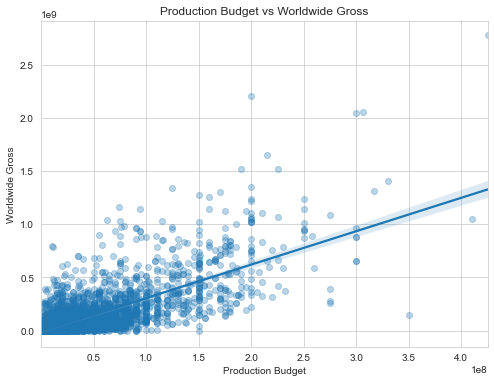

In [131]:
plt.figure(figsize=(8, 6))
sns.regplot(x='production_budget', y='worldwide_gross', data=tmdb_tn_merged,
            scatter_kws={'alpha':0.3})  # Adjust transparency of scatter points
plt.title('Production Budget vs Worldwide Gross')
plt.xlabel('Production Budget')
plt.ylabel('Worldwide Gross')
plt.show()

#### Domestic Gross

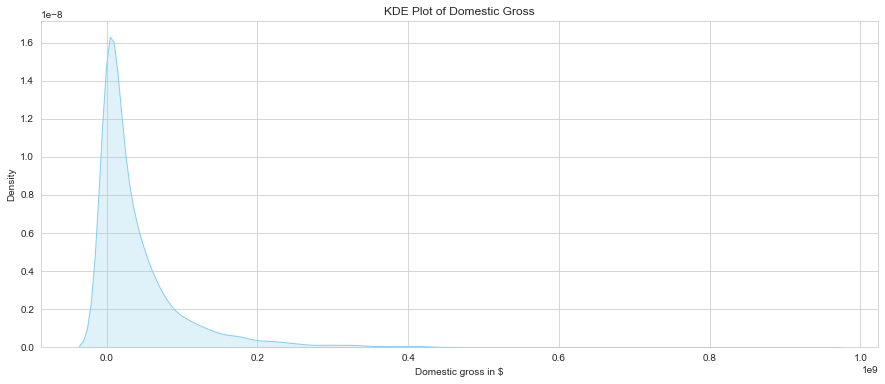

In [86]:
plt.figure(figsize=(15, 6))
sns.kdeplot(data=tmdb_tn_merged, x='domestic_gross', fill=True, color='skyblue')
plt.title('KDE Plot of Domestic Gross')
plt.xlabel('Domestic gross in $')
plt.ylabel('Density')
plt.show()

In [148]:
#IQR Domestic Gross
Q1 = tmdb_tn_merged['domestic_gross'].quantile(0.25)
Q3 = tmdb_tn_merged['domestic_gross'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers = tmdb_tn_merged[(tmdb_tn_merged['domestic_gross'] < lower_bound) | (tmdb_tn_merged['domestic_gross'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 1530999.25
Q3 (75th percentile): 52902918.75
IQR: 51371919.5
Lower Bound: -75526880.0
Upper Bound: 129960798.0

Outliers found:
      id                                        title  production_budget  \
0      1                                       Avatar          425000000   
1      2  Pirates of the Caribbean: On Stranger Tides          410600000   
3      4                      Avengers: Age of Ultron          330600000   
4      5            Star Wars Ep. VIII: The Last Jedi          317000000   
5      6         Star Wars Ep. VII: The Force Awakens          306000000   
...   ..                                          ...                ...   
4381  50                                        Split            5000000   
4707  68                           Gone with the Wind            3900000   
4805  64              National Lampoon's Animal House            3000000   
5263  18              Snow White and the Seven Dwarf

In [155]:
tmdb_tn_merged_cleaned = tmdb_tn_merged[(tmdb_tn_merged['domestic_gross'] >= lower_bound) & (tmdb_tn_merged['domestic_gross'] <= upper_bound)]

print("Original DataFrame shape:", tmdb_tn_merged.shape)
print("Cleaned DataFrame shape:", tmdb_tn_merged_cleaned.shape)

Original DataFrame shape: (5940, 6)
Cleaned DataFrame shape: (5796, 6)


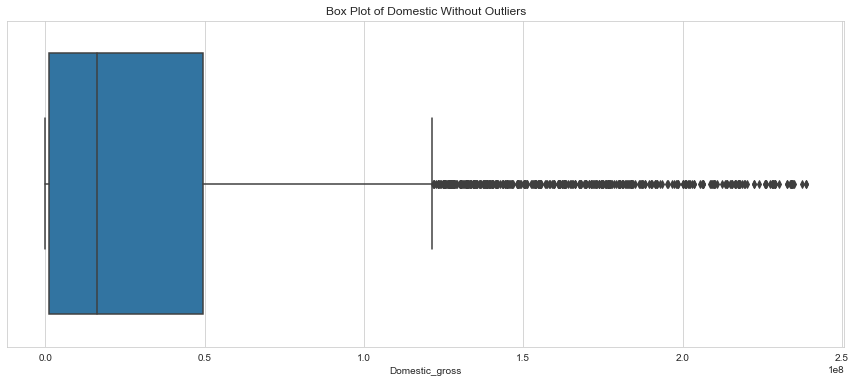

In [157]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=tmdb_tn_merged_cleaned['domestic_gross'])
plt.title('Box Plot of Domestic Without Outliers')
plt.xlabel('Domestic_gross')
plt.show()

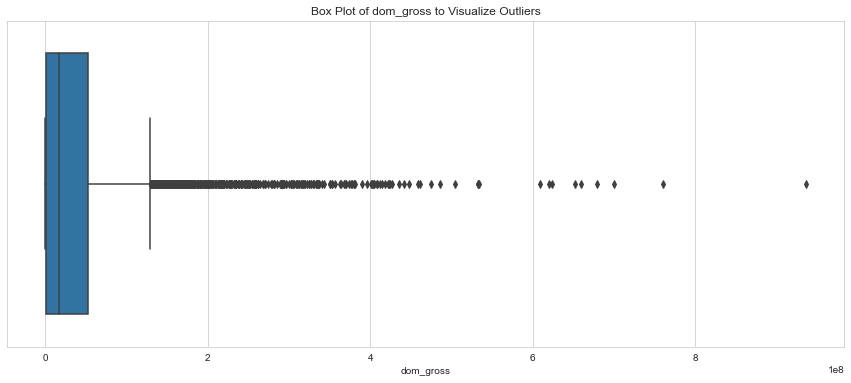

In [159]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=tmdb_tn_merged['domestic_gross'])
plt.title('Box Plot of dom_gross to Visualize Outliers')
plt.xlabel('dom_gross')
plt.show()

#### Production Budget

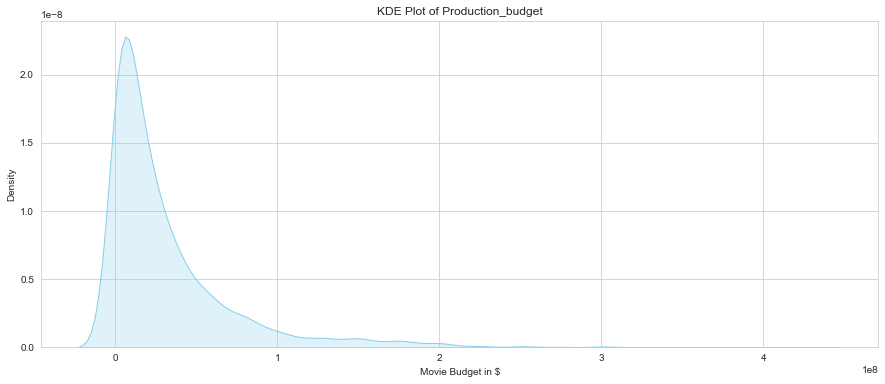

In [160]:
plt.figure(figsize=(15, 6))
sns.kdeplot(data=tmdb_tn_merged, x='production_budget', fill=True, color='skyblue')
plt.title('KDE Plot of Production_budget')
plt.xlabel('Movie Budget in $')
plt.ylabel('Density')
plt.show()

In [163]:
#IQR Production Budget
Q1 = tmdb_tn_merged['production_budget'].quantile(0.25)
Q3 = tmdb_tn_merged['production_budget'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers = tmdb_tn_merged[(tmdb_tn_merged['production_budget'] < lower_bound) | (tmdb_tn_merged['production_budget'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 5000000.0
Q3 (75th percentile): 40000000.0
IQR: 35000000.0
Lower Bound: -47500000.0
Upper Bound: 92500000.0

Outliers found:
     id                                        title  production_budget  \
0     1                                       Avatar          425000000   
1     2  Pirates of the Caribbean: On Stranger Tides          410600000   
2     3                                 Dark Phoenix          350000000   
3     4                      Avengers: Age of Ultron          330600000   
4     5            Star Wars Ep. VIII: The Last Jedi          317000000   
..   ..                                          ...                ...   
452  28                      Lara Croft: Tomb Raider           94000000   
453  29                 Kingsman: The Secret Service           94000000   
454  29                 Kingsman: The Secret Service           94000000   
455  30                            Jurassic Park III           93

In [164]:
tmdb_tn_merged_cleaned = tmdb_tn_merged[(tmdb_tn_merged['production_budget'] >= lower_bound) & (tmdb_tn_merged['production_budget'] <= upper_bound)]

print("Original DataFrame shape:", tmdb_tn_merged.shape)
print("Cleaned DataFrame shape:", tmdb_tn_merged_cleaned.shape)

Original DataFrame shape: (5940, 6)
Cleaned DataFrame shape: (5483, 6)


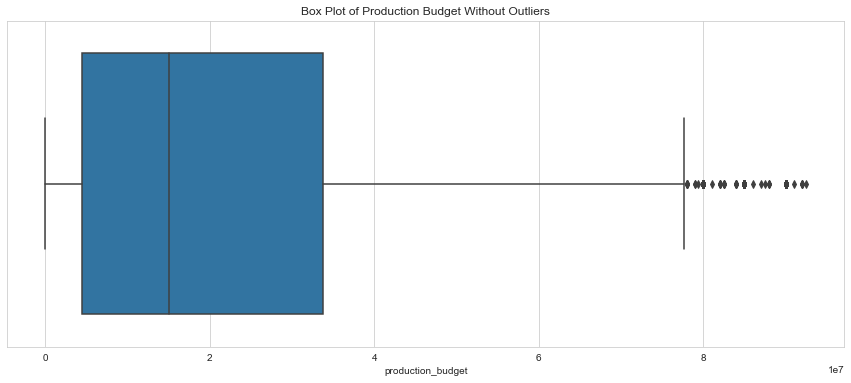

In [165]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=tmdb_tn_merged_cleaned['production_budget'])
plt.title('Box Plot of Production Budget Without Outliers')
plt.xlabel('production_budget')
plt.show()

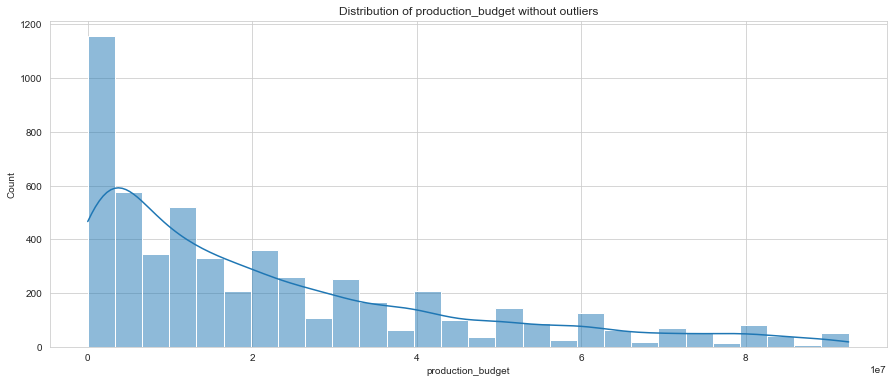

In [167]:
plt.figure(figsize=(15, 6))
sns.histplot(tmdb_tn_merged_cleaned['production_budget'], kde=True)
plt.title('Distribution of production_budget without outliers')
plt.xlabel('production_budget')
plt.ylabel('Count')
plt.show()

#### Worldwide Gross 

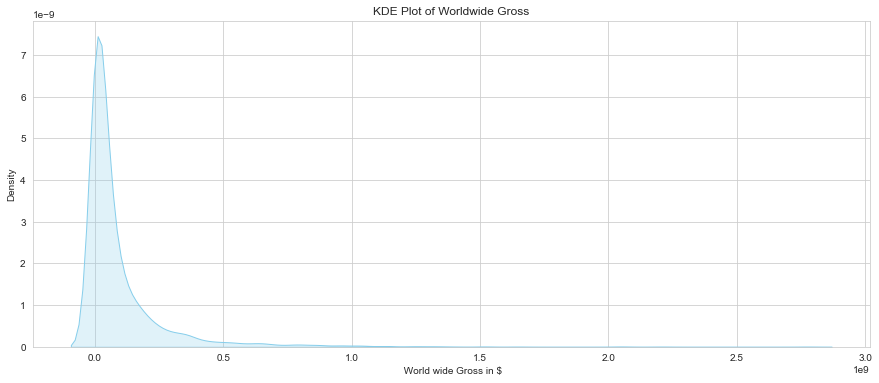

In [134]:
#WORLDWIDE GROSS
plt.figure(figsize=(15, 6))
sns.kdeplot(data=tmdb_tn_merged, x='worldwide_gross', fill=True, color='skyblue')
plt.title('KDE Plot of Worldwide Gross')
plt.xlabel(' World wide Gross in $')
plt.ylabel('Density')
plt.show()

In [149]:
#IQR
Q1 = tmdb_tn_merged['worldwide_gross'].quantile(0.25)
Q3 = tmdb_tn_merged['worldwide_gross'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers = tmdb_tn_merged[(tmdb_tn_merged['worldwide_gross'] < lower_bound) | (tmdb_tn_merged['worldwide_gross'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 4310483.0
Q3 (75th percentile): 98990359.25
IQR: 94679876.25
Lower Bound: -137709331.375
Upper Bound: 241010173.625

Outliers found:
      id                                        title  production_budget  \
0      1                                       Avatar          425000000   
1      2  Pirates of the Caribbean: On Stranger Tides          410600000   
3      4                      Avengers: Age of Ultron          330600000   
4      5            Star Wars Ep. VIII: The Last Jedi          317000000   
5      6         Star Wars Ep. VII: The Force Awakens          306000000   
...   ..                                          ...                ...   
4707  68                           Gone with the Wind            3900000   
4729  90                               The Full Monty            3500000   
4919  76                                   Cinderella            2900000   
5497  47                                       

In [150]:
# Filter out the outliers and create a tmdb_tn_mereged, cleaned DataFrame
tmdb_tn_merged_cleaned = tmdb_tn_merged[(tmdb_tn_merged['worldwide_gross'] >= lower_bound) & (tmdb_tn_merged['worldwide_gross'] <= upper_bound)]

print("Original DataFrame shape:", tmdb_tn_merged.shape)
print("Cleaned DataFrame shape:", tmdb_tn_merged_cleaned.shape)

Original DataFrame shape: (5940, 6)
Cleaned DataFrame shape: (5315, 6)


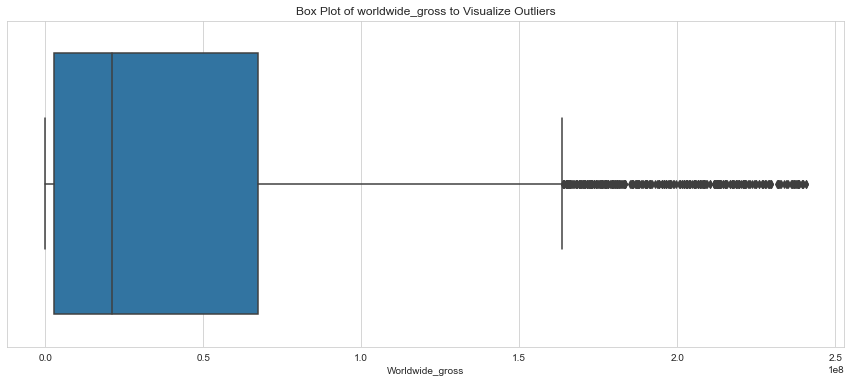

In [151]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=tmdb_tn_merged_cleaned['worldwide_gross'])
plt.title('Box Plot of worldwide_gross to Visualize Outliers')
plt.xlabel('Worldwide_gross')
plt.show()

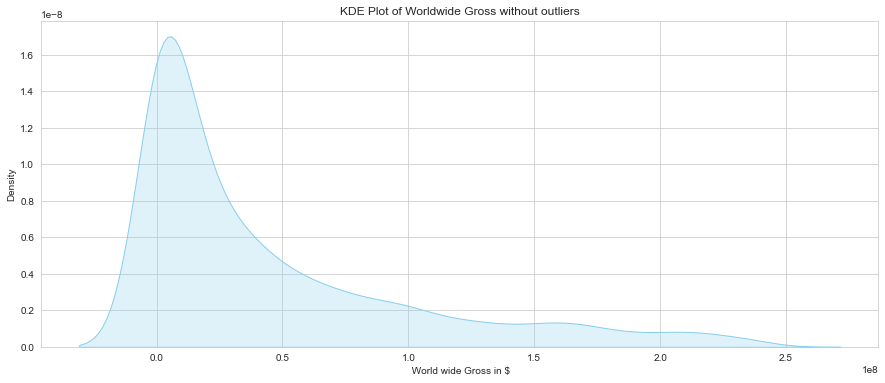

In [152]:
plt.figure(figsize=(15, 6))
sns.kdeplot(data=tmdb_tn_merged_cleaned, x='worldwide_gross', fill=True, color='skyblue')
plt.title('KDE Plot of Worldwide Gross without outliers')
plt.xlabel(' World wide Gross in $')
plt.ylabel('Density')
plt.show()

#### Release Year

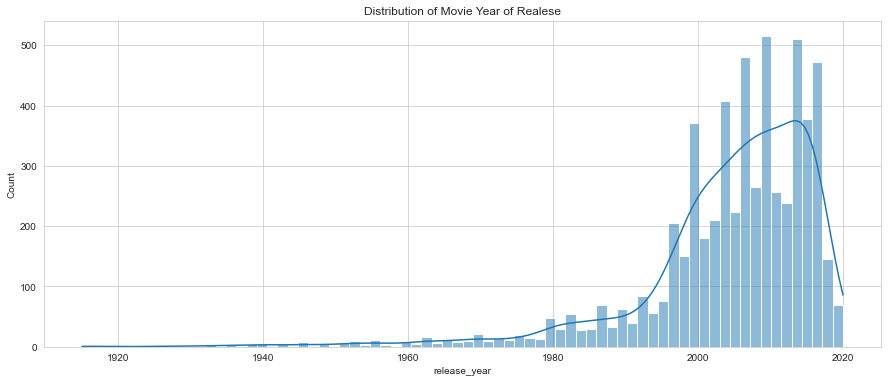

In [168]:
plt.figure(figsize=(15, 6))
sns.histplot(tmdb_tn_merged['release_year'], kde=True)
plt.title('Distribution of Movie Year of Realese')
plt.xlabel('release_year')
plt.ylabel('Count')
plt.show()

In [169]:
#IQR Release Year
Q1 = tmdb_tn_merged['release_year'].quantile(0.25)
Q3 = tmdb_tn_merged['release_year'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers = tmdb_tn_merged[(tmdb_tn_merged['release_year'] < lower_bound) | (tmdb_tn_merged['release_year'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 2000.0
Q3 (75th percentile): 2013.0
IQR: 13.0
Lower Bound: 1980.5
Upper Bound: 2032.5

Outliers found:
       id                           title  production_budget  domestic_gross  \
1029   89                        Superman           55000000       134218018   
1382   34                   Heaven's Gate           44000000         3484331   
1398   50                       Cleopatra           42000000        57000000   
1573   20               Raise the Titanic           40000000         7000000   
1696   38   Star Trek: The Motion Picture           35000000        82258456   
...   ...                             ...                ...             ...   
5840   84  Over the Hill to the Poorhouse             100000         3000000   
5843   87                    Penitentiary             100000          287000   
5856  100      The Last House on the Left              87000         3100000   
5870   14     The Brain That Wouldn't

In [170]:
# Filter out the outliers and create a tmdb_tn_mereged, cleaned DataFrame
tmdb_tn_merged_cleaned = tmdb_tn_merged[(tmdb_tn_merged['release_year'] >= lower_bound) & (tmdb_tn_merged['release_year'] <= upper_bound)]

print("Original DataFrame shape:", tmdb_tn_merged.shape)
print("Cleaned DataFrame shape:", tmdb_tn_merged_cleaned.shape)

Original DataFrame shape: (5940, 6)
Cleaned DataFrame shape: (5640, 6)


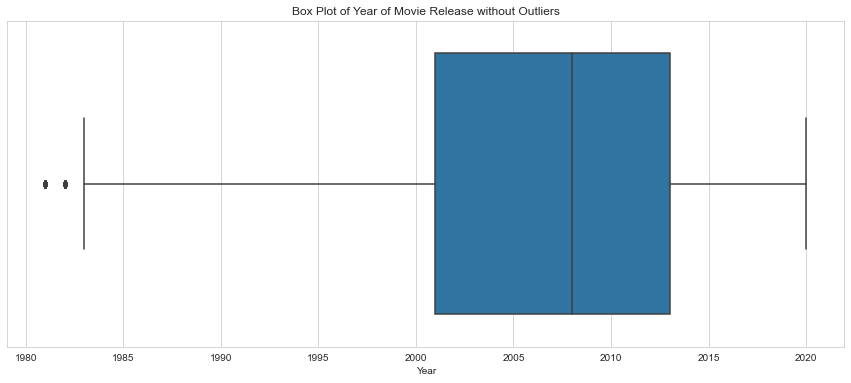

In [171]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=tmdb_tn_merged_cleaned['release_year'])
plt.title('Box Plot of Year of Movie Release without Outliers')
plt.xlabel('Year')
plt.show()

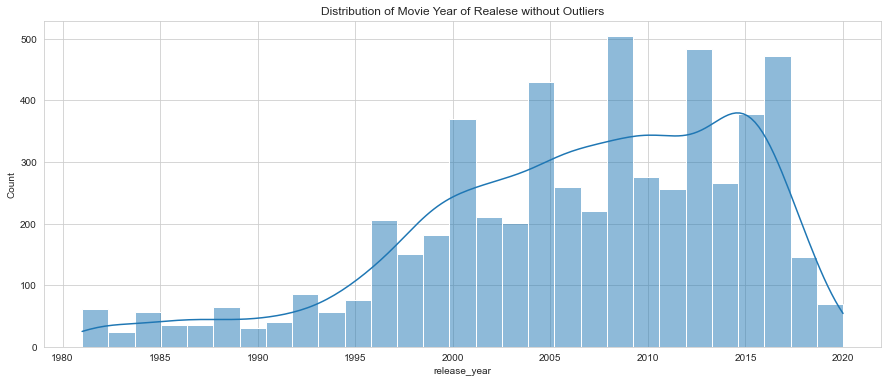

In [174]:
plt.figure(figsize=(15, 6))
sns.histplot(tmdb_tn_merged_cleaned['release_year'], kde=True)
plt.title('Distribution of Movie Year of Realese without Outliers')
plt.xlabel('release_year')
plt.ylabel('Count')
plt.show()


### Rotten Tomatoes Movie information and Reviews

In [175]:
# ROTTEN TOMATOES
rt_combined_df.describe()

,id,runtime,Review_counts,Freshness_score
count,1560.000000,1560.000000,1135.000000,1135.000000
mean,1007.303846,103.891667,47.957709,0.577074
std,579.164527,24.410230,56.574357,0.313605
min,1.000000,5.000000,1.000000,0.000000
25%,504.750000,91.000000,7.000000,0.333333
50%,1007.500000,100.000000,23.000000,0.635514
75%,1503.250000,114.000000,73.500000,0.846154
max,2000.000000,358.000000,338.000000,1.000000


In [184]:
print("--- 1. Re-run Initial Data Profiling/Summary Statistics ---")
print("\n1.1. `df.info()` - Check Data Types and Non-Null Counts:")
rt_combined_df.info()

print("\n1.2. `df.describe()` - Summary Statistics for Numerical Columns:")
print(rt_combined_df.describe())

print("\n1.3. `df.nunique()` - Number of Unique Values per Column:")
print(rt_combined_df.nunique())

print("\n1.4. `df.isnull().sum()` - Check for Remaining Missing Values:")
print(rt_combined_df.isnull().sum())
print("\n" + "="*50 + "\n")

--- 1. Re-run Initial Data Profiling/Summary Statistics ---

1.1. `df.info()` - Check Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1560 entries, 0 to 1559
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1560 non-null   int64         
 1   synopsis         1560 non-null   object        
 2   rating           1560 non-null   object        
 3   genre            1560 non-null   object        
 4   director         1560 non-null   object        
 5   writer           1560 non-null   object        
 6   theater_date     1201 non-null   datetime64[ns]
 7   dvd_date         1201 non-null   datetime64[ns]
 8   runtime          1560 non-null   float64       
 9   studio           1560 non-null   object        
 10  Review_counts    1135 non-null   float64       
 11  Freshness_score  1135 non-null   float64       
dtypes: datetime64[ns](2), float6

#### Freshness Score

In [185]:
rt_combined_df.columns

Index(['id', 'synopsis', 'rating', 'genre', 'director', 'writer',
       'theater_date', 'dvd_date', 'runtime', 'studio', 'Review_counts',
       'Freshness_score'],
      dtype='object')

In [186]:
fresh_median = rt_combined_df['Freshness_score'].median() 
fresh_median

0.6355140186915887

In [187]:
rt_combined_df_cleaned=rt_combined_df.copy()

In [188]:
rt_combined_df_cleaned.loc[:, 'Freshness_score'] = rt_combined_df_cleaned.loc[:, 'Freshness_score'].fillna(fresh_median)

In [180]:
rt_combined_df_cleaned

,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,runtime,studio,Review_counts,Freshness_score
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,1971-10-09,2001-09-25,104.0,Unknown,NaN,0.635514
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,2012-08-17,2013-01-01,108.0,Entertainment One,163.0,0.631902
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,1996-09-13,2000-04-18,116.0,Unknown,23.0,0.782609
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,1994-12-09,1997-08-27,128.0,Unknown,57.0,0.561404
4,7,Unknown,NR,Drama|Romance,Rodney Bennett,Giles Cooper,NaT,NaT,200.0,Unknown,NaN,0.635514
...,...,...,...,...,...,...,...,...,...,...,...,...
1555,1996,Forget terrorists or hijackers -- there's a ha...,R,Action and Adventure|Horror|Mystery and Suspense,Unknown,Unknown,2006-08-18,2007-01-02,106.0,New Line Cinema,143.0,0.671329
1556,1997,The popular Saturday Night Live sketch was exp...,PG,Comedy|Science Fiction and Fantasy,Steve Barron,Terry Turner|Tom Davis|Dan Aykroyd|Bonnie Turner,1993-07-23,2001-04-17,88.0,Paramount Vantage,28.0,0.357143
1557,1998,"Based on a novel by Richard Powell, when the l...",G,Classics|Comedy|Drama|Musical and Performing Arts,Gordon Douglas,Unknown,1962-01-01,2004-05-11,111.0,Unknown,2.0,1.000000
1558,1999,The Sandlot is a coming-of-age story about a g...,PG,Comedy|Drama|Kids and Family|Sports and Fitness,David Mickey Evans,David Mickey Evans|Robert Gunter,1993-04-01,2002-01-29,101.0,Unknown,46.0,0.586957


In [191]:
Q1 = rt_combined_df_cleaned['Freshness_score'].quantile(0.25)
Q3 = rt_combined_df_cleaned['Freshness_score'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers = rt_combined_df_cleaned[(rt_combined_df_cleaned['Freshness_score'] < lower_bound) | (rt_combined_df_cleaned['Freshness_score'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 0.433
Q3 (75th percentile): 0.7708387942332897
IQR: 0.3378387942332897
Lower Bound: -0.07375819134993461
Upper Bound: 1.2775969855832243

No outliers found.


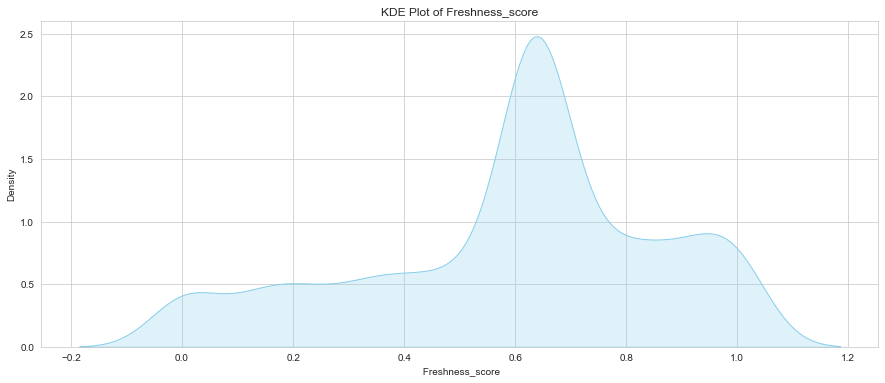

In [193]:
#FRESHNESS SCORE
plt.figure(figsize=(15, 6))
sns.kdeplot(data=rt_combined_df_cleaned, x='Freshness_score', fill=True, color='skyblue')
plt.title('KDE Plot of Freshness_score')
plt.xlabel(' Freshness_score')
plt.ylabel('Density')
plt.show()


#### Review Counts

In [194]:
rt_combined_df_cleaned.isnull().sum()

id                   0
synopsis             0
rating               0
genre                0
director             0
writer               0
theater_date       359
dvd_date           359
runtime              0
studio               0
Review_counts      425
Freshness_score      0
dtype: int64

In [204]:
#Dropping Theater and dvd date
rt_combined_df_cleaned = rt_combined_df_cleaned.drop(columns=['theater_date', 'dvd_date'] , axis=1)
rt_combined_df_cleaned

,id,synopsis,rating,genre,director,writer,runtime,studio,Review_counts,Freshness_score
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,104.0,Unknown,0.0,0.635514
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,108.0,Entertainment One,163.0,0.631902
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,116.0,Unknown,23.0,0.782609
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,128.0,Unknown,57.0,0.561404
4,7,Unknown,NR,Drama|Romance,Rodney Bennett,Giles Cooper,200.0,Unknown,0.0,0.635514
...,...,...,...,...,...,...,...,...,...,...
1555,1996,Forget terrorists or hijackers -- there's a ha...,R,Action and Adventure|Horror|Mystery and Suspense,Unknown,Unknown,106.0,New Line Cinema,143.0,0.671329
1556,1997,The popular Saturday Night Live sketch was exp...,PG,Comedy|Science Fiction and Fantasy,Steve Barron,Terry Turner|Tom Davis|Dan Aykroyd|Bonnie Turner,88.0,Paramount Vantage,28.0,0.357143
1557,1998,"Based on a novel by Richard Powell, when the l...",G,Classics|Comedy|Drama|Musical and Performing Arts,Gordon Douglas,Unknown,111.0,Unknown,2.0,1.000000
1558,1999,The Sandlot is a coming-of-age story about a g...,PG,Comedy|Drama|Kids and Family|Sports and Fitness,David Mickey Evans,David Mickey Evans|Robert Gunter,101.0,Unknown,46.0,0.586957


In [198]:
rt_combined_df_cleaned.loc[:,'Review_counts'] = rt_combined_df_cleaned.loc[:, 'Review_counts'].fillna(0)

In [205]:
rt_combined_df_cleaned.isnull().sum()

id                 0
synopsis           0
rating             0
genre              0
director           0
writer             0
runtime            0
studio             0
Review_counts      0
Freshness_score    0
dtype: int64

In [214]:
#IQR Review Counts

Q1 = rt_combined_df_cleaned['Review_counts'].quantile(0.25)
Q3 = rt_combined_df_cleaned['Review_counts'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers = rt_combined_df_cleaned[(rt_combined_df_cleaned['Review_counts'] < lower_bound) | (rt_combined_df_cleaned['Review_counts'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 0.0
Q3 (75th percentile): 28.0
IQR: 28.0
Lower Bound: -42.0
Upper Bound: 70.0

Outliers found:
        id                                           synopsis   rating  \
5        8  The year is 1942. As the Allies unite overseas...       PG   
6       10  Some cast and crew from NBC's highly acclaimed...    PG-13   
7       13  Stewart Kane, an Irishman living in the Austra...        R   
10      17                                            Unknown  Unknown   
24      34  Director John Woo brings Hong Kong-style marti...    PG-13   
...    ...                                                ...      ...   
1499  1931  Mark Felt - The Man Who Brought Down the White...    PG-13   
1506  1940  The debut project from co-star Michael Douglas...        R   
1509  1943  A boy from a broken home finds a friend in an ...        R   
1512  1946  Alex Browning, is embarking on a trip to Paris...        R   
1546  1986  Aki Kaurismaki's Th

In [215]:
rt_combined_df_cleaned = rt_combined_df_cleaned[(rt_combined_df_cleaned['Review_counts'] >= lower_bound) & (rt_combined_df_cleaned['Review_counts'] <= upper_bound)]

print("Original DataFrame shape:", rt_combined_df.shape)
print("Cleaned DataFrame shape:", rt_combined_df_cleaned.shape)

Original DataFrame shape: (1560, 12)
Cleaned DataFrame shape: (1266, 10)


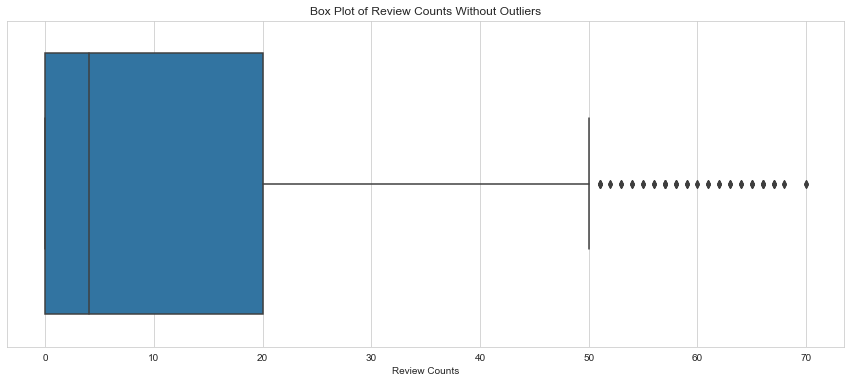

In [218]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=rt_combined_df_cleaned['Review_counts'])
plt.title('Box Plot of Review Counts Without Outliers')
plt.xlabel('Review Counts')
plt.show()

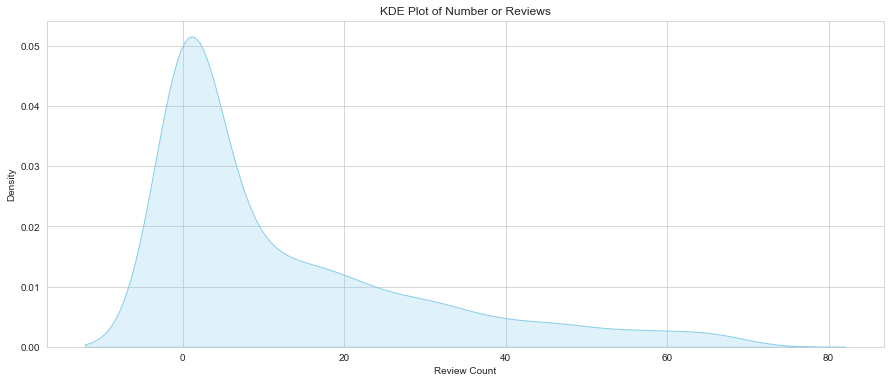

In [219]:
plt.figure(figsize=(15, 6))
sns.kdeplot(data=rt_combined_df_cleaned, x='Review_counts', fill=True, color='skyblue')
plt.title('KDE Plot of Number or Reviews')
plt.xlabel('Review Count')
plt.ylabel('Density')
plt.show()

#### Runtime

In [220]:
#IQR Runtime
Q1 = rt_combined_df_cleaned['runtime'].quantile(0.25)
Q3 = rt_combined_df_cleaned['runtime'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers = rt_combined_df_cleaned[(rt_combined_df_cleaned['runtime'] < lower_bound) | (rt_combined_df_cleaned['runtime'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 90.0
Q3 (75th percentile): 111.0
IQR: 21.0
Lower Bound: 58.5
Upper Bound: 142.5

Outliers found:
        id                                           synopsis rating  \
4        7                                            Unknown     NR   
58      72  In Harm's Way, based on James Bassett's novel ...      R   
66      84  Despite excellent camerawork and smooth contin...     NR   
87     109                                            Unknown     NR   
128    163  This made-for-cable Civil War saga chronicles ...     NR   
...    ...                                                ...    ...   
1358  1753  Carmel Myers' co-star in this amusing farce is...     NR   
1450  1867  Filmed in panoramic Cinerama, this star-studde...      G   
1468  1889  Milos Foreman's cinematic adaptation of E.L. D...     PG   
1490  1918  A collection of 15 chapters from Tarzan and th...     NR   
1508  1942  Set in the rustic surroundings of a vil

In [221]:
rt_combined_df_cleaned = rt_combined_df_cleaned[(rt_combined_df_cleaned['runtime'] >= lower_bound) & (rt_combined_df_cleaned['runtime'] <= upper_bound)]

print("Original DataFrame shape:", rt_combined_df.shape)
print("Cleaned DataFrame shape:", rt_combined_df_cleaned.shape)

Original DataFrame shape: (1560, 12)
Cleaned DataFrame shape: (1185, 10)


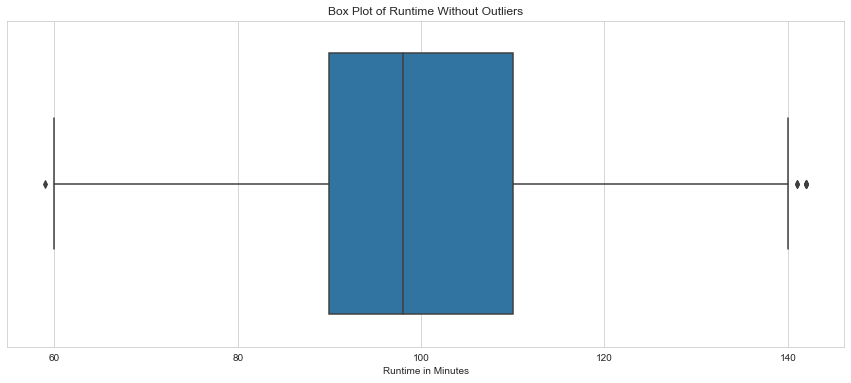

In [222]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=rt_combined_df_cleaned['runtime'])
plt.title('Box Plot of Runtime Without Outliers')
plt.xlabel('Runtime in Minutes')
plt.show()

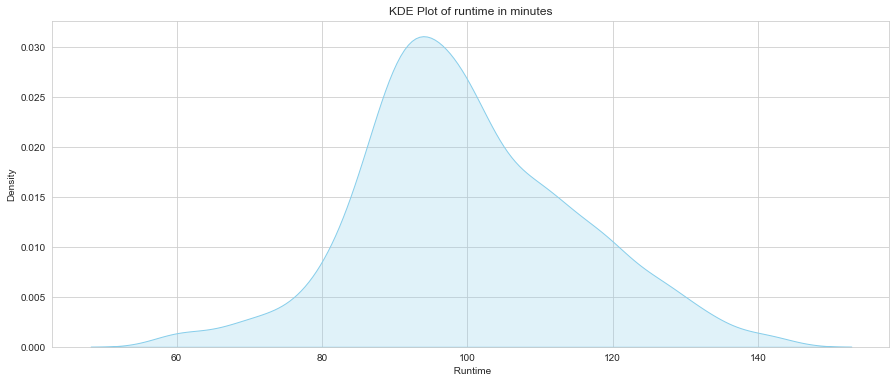

In [225]:
plt.figure(figsize=(15, 6))
sns.kdeplot(data=rt_combined_df_cleaned, x='runtime', fill=True, color='skyblue')
plt.title('KDE Plot of runtime in minutes')
plt.xlabel(' Runtime')
plt.ylabel('Density')
plt.show()

## Directors And Writer Metrics

### Writers

In [230]:
print("--- 1. Re-run Initial Data Profiling/Summary Statistics ---")
print("\n1.1. `df.info()` - Check Data Types and Non-Null Counts:")
top_writers_by_reviews.info()

print("\n1.2. `df.describe()` - Summary Statistics for Numerical Columns:")
print(top_writers_by_reviews.describe())

print("\n1.3. `df.nunique()` - Number of Unique Values per Column:")
print(top_writers_by_reviews.nunique())

print("\n1.4. `df.isnull().sum()` - Check for Remaining Missing Values:")
print(top_writers_by_reviews.isnull().sum())
print("\n" + "="*50 + "\n")

--- 1. Re-run Initial Data Profiling/Summary Statistics ---

1.1. `df.info()` - Check Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 10 entries, 632 to 770
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   writer                10 non-null     object 
 1   writer_avg_freshness  10 non-null     float64
 2   writer_avg_reviews    10 non-null     float64
 3   writer_movie_count    10 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 400.0+ bytes

1.2. `df.describe()` - Summary Statistics for Numerical Columns:
       writer_avg_freshness  writer_avg_reviews  writer_movie_count
count             10.000000           10.000000                10.0
mean               0.859882          265.400000                 1.0
std                0.166615           26.916331                 0.0
min                0.485944          243.000000                 1.

#### writer_avg_freshness

In [231]:
Q1 = top_writers_by_reviews['writer_avg_freshness'].quantile(0.25)
Q3 = top_writers_by_reviews['writer_avg_freshness'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers =top_writers_by_reviews[(top_writers_by_reviews['writer_avg_freshness'] < lower_bound) | (top_writers_by_reviews['writer_avg_freshness'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 0.9001214078596855
Q3 (75th percentile): 0.9472832980972515
IQR: 0.047161890237566007
Lower Bound: 0.8293785725033365
Upper Bound: 1.0180261334536005

Outliers found:
                                                writer  writer_avg_freshness  \
650                     Mel Gibson|Benedict Fitzgerald              0.485944   
770  Peter Jackson|Philippa Boyens|Guillermo del To...              0.621399   

     writer_avg_reviews  writer_movie_count  
650               249.0                   1  
770               243.0                   1  


In [238]:
top_writers_by_reviews_cleaned = top_writers_by_reviews[(top_writers_by_reviews['writer_avg_freshness'] >= lower_bound) & (top_writers_by_reviews['writer_avg_freshness'] <= upper_bound)]

print("Original DataFrame shape:", top_writers_by_reviews.shape)
print("Cleaned DataFrame shape:",top_writers_by_reviews_cleaned.shape)

Original DataFrame shape: (10, 4)
Cleaned DataFrame shape: (8, 4)


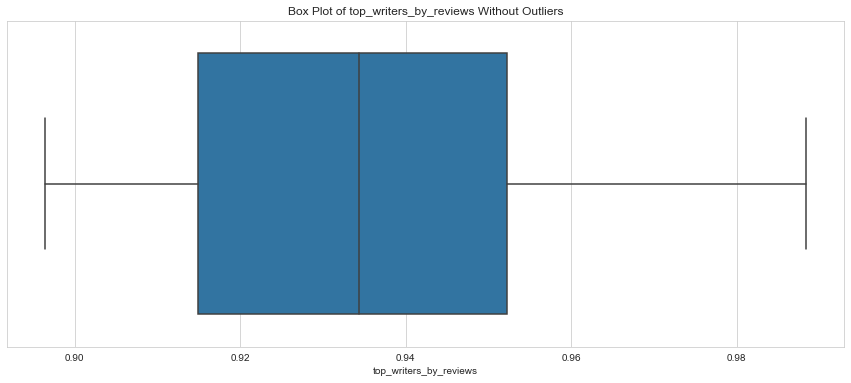

In [239]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=top_writers_by_reviews_cleaned['writer_avg_freshness'])
plt.title('Box Plot of top_writers_by_reviews Without Outliers')
plt.xlabel('top_writers_by_reviews')
plt.show()

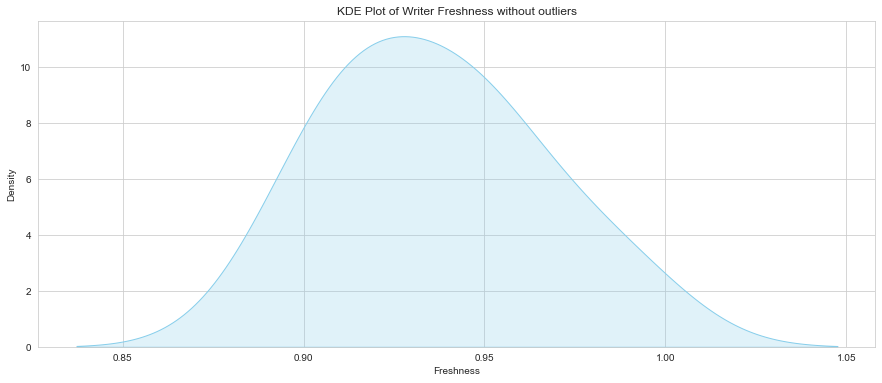

In [242]:
plt.figure(figsize=(15, 6))
sns.kdeplot(data=top_writers_by_reviews_cleaned, x='writer_avg_freshness', fill=True, color='skyblue')
plt.title('KDE Plot of Writer Freshness without outliers')
plt.xlabel('Freshness')
plt.ylabel('Density')
plt.show()

#### writer_movie_count

In [243]:
Q1 = top_writers_by_reviews['writer_movie_count'].quantile(0.25)
Q3 = top_writers_by_reviews['writer_movie_count'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers =top_writers_by_reviews[(top_writers_by_reviews['writer_movie_count'] < lower_bound) | (top_writers_by_reviews['writer_movie_count'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 1.0
Q3 (75th percentile): 1.0
IQR: 0.0
Lower Bound: 1.0
Upper Bound: 1.0

No outliers found.


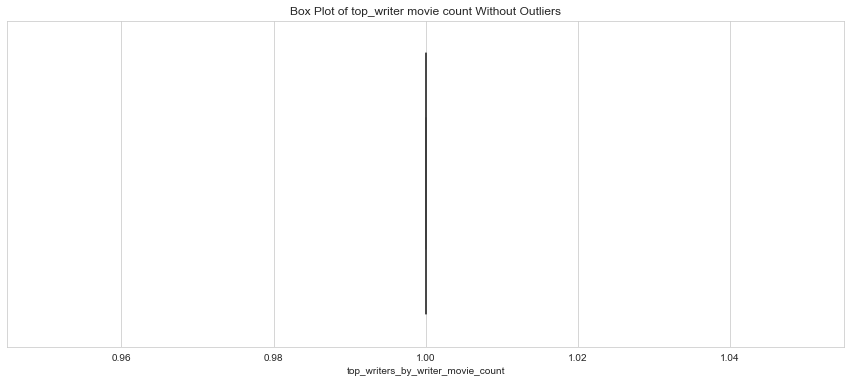

In [244]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=top_writers_by_reviews_cleaned['writer_movie_count'])
plt.title('Box Plot of top_writer movie count Without Outliers')
plt.xlabel('top_writers_by_writer_movie_count')
plt.show()

#### writer_avg_reviews   

In [247]:
Q1 = top_writers_by_reviews['writer_avg_reviews'].quantile(0.25)
Q3 = top_writers_by_reviews['writer_avg_reviews'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers =top_writers_by_reviews[(top_writers_by_reviews['writer_avg_reviews'] < lower_bound) | (top_writers_by_reviews['writer_avg_reviews'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 252.75
Q3 (75th percentile): 261.5
IQR: 8.75
Lower Bound: 239.625
Upper Bound: 274.625

Outliers found:
              writer  writer_avg_freshness  writer_avg_reviews  \
632  Martin McDonagh              0.911243               338.0   
423      James Ivory              0.949091               275.0   

     writer_movie_count  
632                   1  
423                   1  


In [248]:
top_writers_by_reviews_cleaned = top_writers_by_reviews[(top_writers_by_reviews['writer_avg_reviews'] >= lower_bound) & (top_writers_by_reviews['writer_avg_reviews'] <= upper_bound)]

print("Original DataFrame shape:", top_writers_by_reviews.shape)
print("Cleaned DataFrame shape:",top_writers_by_reviews_cleaned.shape)

Original DataFrame shape: (10, 4)
Cleaned DataFrame shape: (8, 4)


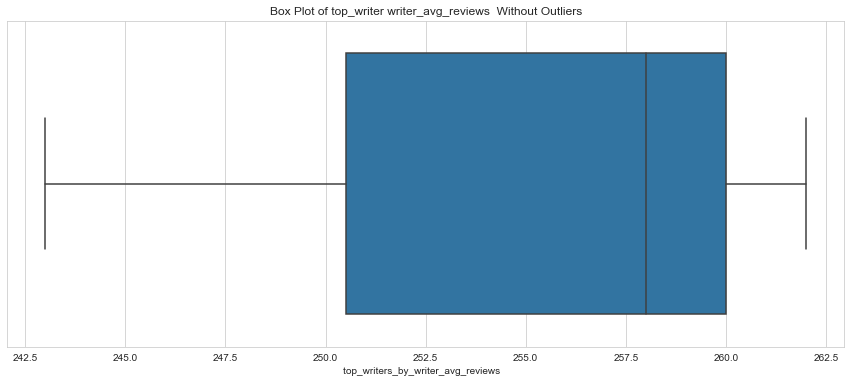

In [249]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=top_writers_by_reviews_cleaned['writer_avg_reviews'])
plt.title('Box Plot of top_writer writer_avg_reviews  Without Outliers')
plt.xlabel('top_writers_by_writer_avg_reviews   ')
plt.show()

### Directors

In [234]:
top_directors_by_reviews.isnull().sum()

director                  0
director_avg_freshness    0
director_avg_reviews      0
director_movie_count      0
dtype: int64

In [251]:
print("--- 1. Re-run Initial Data Profiling/Summary Statistics ---")
print("\n1.1. `df.info()` - Check Data Types and Non-Null Counts:")
top_directors_by_reviews.info()

print("\n1.2. `df.describe()` - Summary Statistics for Numerical Columns:")
print(top_directors_by_reviews.describe())

print("\n1.3. `df.nunique()` - Number of Unique Values per Column:")
print(top_directors_by_reviews.nunique())

print("\n1.4. `df.isnull().sum()` - Check for Remaining Missing Values:")
print(top_directors_by_reviews.isnull().sum())
print("\n" + "="*50 + "\n")

--- 1. Re-run Initial Data Profiling/Summary Statistics ---

1.1. `df.info()` - Check Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 10 entries, 659 to 935
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   director                10 non-null     object 
 1   director_avg_freshness  10 non-null     float64
 2   director_avg_reviews    10 non-null     float64
 3   director_movie_count    10 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 400.0+ bytes

1.2. `df.describe()` - Summary Statistics for Numerical Columns:
       director_avg_freshness  director_avg_reviews  director_movie_count
count               10.000000             10.000000             10.000000
mean                 0.855871            257.850000              1.100000
std                  0.153451             32.496196              0.316228
min                  0.485944 

#### director_avg_freshness

In [252]:
Q1 = top_directors_by_reviews['director_avg_freshness'].quantile(0.25)
Q3 = top_directors_by_reviews['director_avg_freshness'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers =top_directors_by_reviews[(top_directors_by_reviews['director_avg_freshness'] < lower_bound) | (top_directors_by_reviews['director_avg_freshness'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 0.8204721788961927
Q3 (75th percentile): 0.943548951048951
IQR: 0.12307677215275825
Lower Bound: 0.6358570206670553
Upper Bound: 1.1281641092780883

Outliers found:
       director  director_avg_freshness  director_avg_reviews  \
678  Mel Gibson                0.485944                 249.0   

     director_movie_count  
678                     1  


In [256]:
top_directors_by_reviews_cleaned = top_directors_by_reviews[(top_directors_by_reviews['director_avg_freshness'] >= lower_bound) & (top_directors_by_reviews['director_avg_freshness'] <= upper_bound)]

print("Original DataFrame shape:",top_directors_by_reviews.shape)
print("Cleaned DataFrame shape:",top_directors_by_reviews_cleaned.shape)

Original DataFrame shape: (10, 4)
Cleaned DataFrame shape: (9, 4)


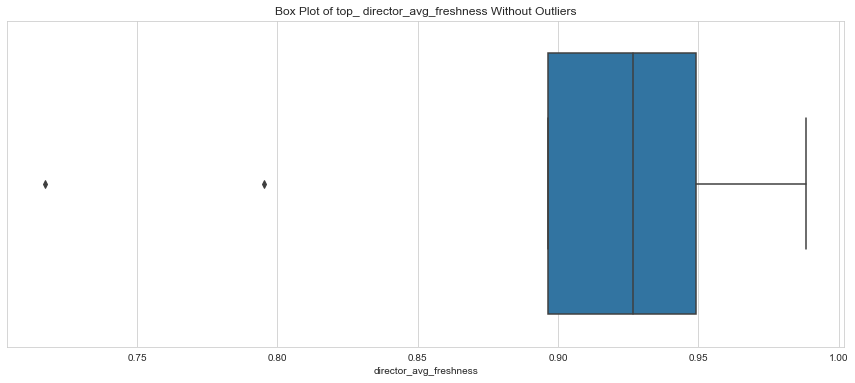

In [258]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=top_directors_by_reviews_cleaned['director_avg_freshness'])
plt.title('Box Plot of top_ director_avg_freshness Without Outliers')
plt.xlabel('director_avg_freshness')
plt.show()

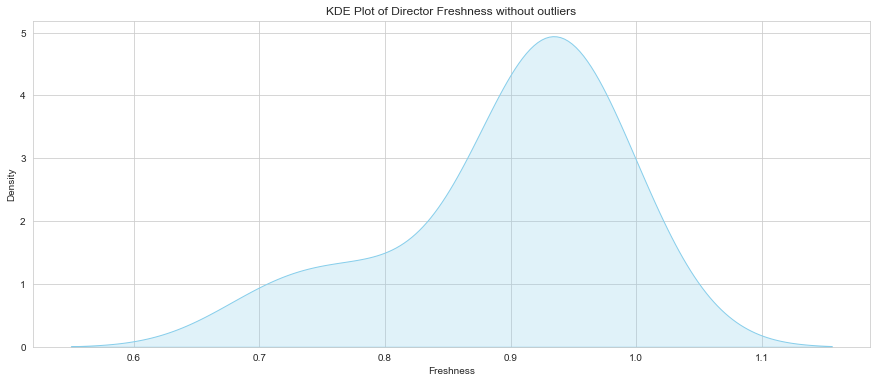

In [259]:
plt.figure(figsize=(15, 6))
sns.kdeplot(data=top_directors_by_reviews_cleaned, x='director_avg_freshness', fill=True, color='skyblue')
plt.title('KDE Plot of Director Freshness without outliers')
plt.xlabel('Freshness')
plt.ylabel('Density')
plt.show()

#### director_avg_reviews

In [261]:

Q1 = top_directors_by_reviews['director_avg_reviews'].quantile(0.25)
Q3 = top_directors_by_reviews['director_avg_reviews'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers =top_directors_by_reviews[(top_directors_by_reviews['director_avg_reviews'] < lower_bound) | (top_directors_by_reviews['director_avg_reviews'] > upper_bound)]

print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

--- Outliers using the IQR method ---
Q1 (25th percentile): 240.0
Q3 (75th percentile): 260.0
IQR: 20.0
Lower Bound: 210.0
Upper Bound: 290.0

Outliers found:
            director  director_avg_freshness  director_avg_reviews  \
659  Martin McDonagh                0.911243                 338.0   

     director_movie_count  
659                     1  


In [262]:
top_directors_by_reviews_cleaned = top_directors_by_reviews[(top_directors_by_reviews['director_avg_reviews'] >= lower_bound) & (top_directors_by_reviews['director_avg_reviews'] <= upper_bound)]

print("Original DataFrame shape:",top_directors_by_reviews.shape)
print("Cleaned DataFrame shape:",top_directors_by_reviews_cleaned.shape)

Original DataFrame shape: (10, 4)
Cleaned DataFrame shape: (9, 4)


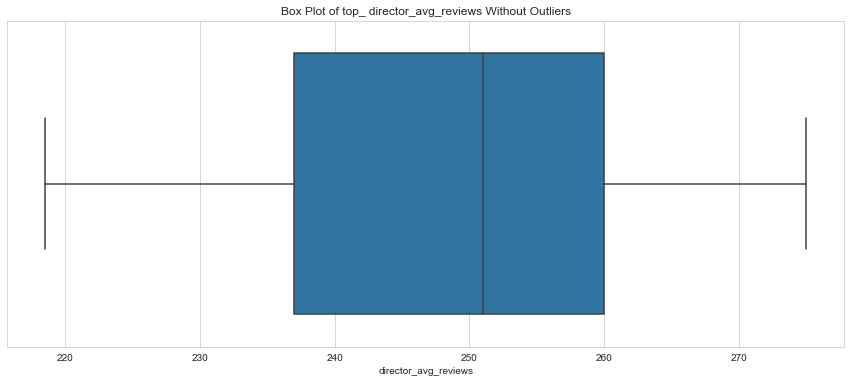

In [264]:
plt.figure(figsize=(15, 6))
sns.boxplot(x=top_directors_by_reviews_cleaned['director_avg_reviews'])
plt.title('Box Plot of top_ director_avg_reviews Without Outliers')
plt.xlabel('director_avg_reviews')
plt.show()

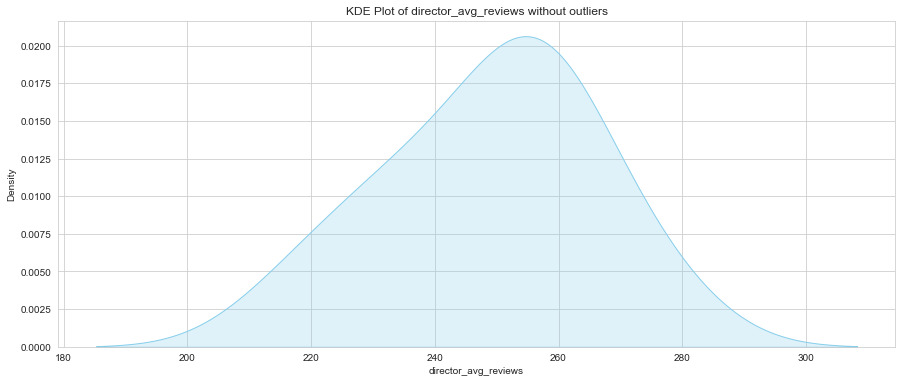

In [263]:
plt.figure(figsize=(15, 6))
sns.kdeplot(data=top_directors_by_reviews_cleaned, x='director_avg_reviews', fill=True, color='skyblue')
plt.title('KDE Plot of director_avg_reviews without outliers')
plt.xlabel('director_avg_reviews')
plt.ylabel('Density')
plt.show()

#### director_movie_count

In [ ]:

Q1 = top_directors_by_reviews['writer_movie_count'].quantile(0.25)
Q3 = top_directors_by_reviews['writer_movie_count'].quantile(0.75)
IQR = Q3 - Q1
​
# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
​
# Find the outliers
outliers =top_directors_by_reviews[(top_directors_by_reviews['writer_movie_count'] < lower_bound) | (top_directors_by_reviews['writer_movie_count'] > upper_bound)]
​
print("--- Outliers using the IQR method ---")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
​
if not outliers.empty:
    print("\nOutliers found:")
    print(outliers)
else:
    print("\nNo outliers found.")

In [265]:
top_directors_by_reviews_cleaned

,director,director_avg_freshness,director_avg_reviews,director_movie_count
625,Luca Guadagnino,0.949091,275.0,1
709,Michel Hazanavicius,0.961538,260.0,1
493,Joel Coen|Ethan Coen,0.926923,260.0,1
76,Ava DuVernay,0.988372,258.0,1
727,Morten Tyldum,0.896414,251.0,1
678,Mel Gibson,0.485944,249.0,1
354,Guillermo del Toro,0.717300,237.0,1
1002,Steven Soderbergh,0.926724,232.0,1
935,Sam Mendes,0.795158,218.5,2


In [266]:
top_writers_by_reviews_cleaned

,writer,writer_avg_freshness,writer_avg_reviews,writer_movie_count
499,John Logan|Robert Wade|Neal Purvis,0.916031,262.0,1
672,Michel Hazanavicius,0.961538,260.0,1
302,Ethan Coen|Joel Coen,0.926923,260.0,1
759,Paul Webb,0.988372,258.0,1
789,Phyllis Nagy,0.941860,258.0,1
359,Graham Moore,0.896414,251.0,1
650,Mel Gibson|Benedict Fitzgerald,0.485944,249.0,1
770,Peter Jackson|Philippa Boyens|Guillermo del To...,0.621399,243.0,1


In [267]:
rt_combined_df_cleaned

,id,synopsis,rating,genre,director,writer,runtime,studio,Review_counts,Freshness_score
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,104.0,Unknown,0.0,0.635514
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,116.0,Unknown,23.0,0.782609
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,128.0,Unknown,57.0,0.561404
8,14,"""Love Ranch"" is a bittersweet love story that ...",R,Drama,Taylor Hackford,Mark Jacobson,117.0,Unknown,42.0,0.142857
9,15,When a diamond expedition in the Congo is lost...,PG-13,Action and Adventure|Mystery and Suspense|Scie...,Frank Marshall,John Patrick Shanley,108.0,Unknown,45.0,0.222222
...,...,...,...,...,...,...,...,...,...,...
1553,1993,A former child actor turned talent agent is hi...,PG,Comedy,James Lapine,Unknown,95.0,Unknown,11.0,0.272727
1556,1997,The popular Saturday Night Live sketch was exp...,PG,Comedy|Science Fiction and Fantasy,Steve Barron,Terry Turner|Tom Davis|Dan Aykroyd|Bonnie Turner,88.0,Paramount Vantage,28.0,0.357143
1557,1998,"Based on a novel by Richard Powell, when the l...",G,Classics|Comedy|Drama|Musical and Performing Arts,Gordon Douglas,Unknown,111.0,Unknown,2.0,1.000000
1558,1999,The Sandlot is a coming-of-age story about a g...,PG,Comedy|Drama|Kids and Family|Sports and Fitness,David Mickey Evans,David Mickey Evans|Robert Gunter,101.0,Unknown,46.0,0.586957


In [268]:
tmdb_tn_merged_cleaned

,id,title,production_budget,domestic_gross,worldwide_gross,release_year
0,1,Avatar,425000000,760507625,2776345279,2009
1,2,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,2011
2,3,Dark Phoenix,350000000,42762350,149762350,2019
3,4,Avengers: Age of Ultron,330600000,459005868,1403013963,2015
4,5,Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747,2017
...,...,...,...,...,...,...
5935,78,Red 11,7000,0,0,2018
5936,79,Following,6000,48482,240495,1999
5937,80,Return to the Land of Wonders,5000,1338,1338,2005
5938,81,A Plague So Pleasant,1400,0,0,2015
